# **TP3 (Parte 1):**
## *Análise de Sentimentos com TF-IDF e Regressão Logística*

In [35]:
!pip install -q scikit-learn matplotlib pandas tqdm

import os
import tarfile
import urllib.request
import urllib.error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tqdm import tqdm

## Questão 1 — Download, carregamento e TF-IDF

In [36]:
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
arquivo = "aclImdb_v1.tar.gz"
diretorio_extraido = "aclImdb"


def baixar_dataset(url, arquivo):
    try:
        print(f"🔽 Baixando dataset atualizado de {url}...")
        urllib.request.urlretrieve(url, arquivo)
        print("✅ Download concluído com sucesso.")
    except urllib.error.URLError as e:
        print(f"❌ Erro ao baixar o dataset: {e.reason}")
        raise SystemExit("Verifique sua conexão ou a URL e tente novamente.")


def extrair_dataset(arquivo, diretorio):
    if os.path.exists(diretorio):
        print(f"🗑️ Removendo diretório antigo: {diretorio}")
        import shutil
        shutil.rmtree(diretorio)

    try:
        print(f"📦 Extraindo {arquivo}...")
        with tarfile.open(arquivo, "r:gz") as tar:
            tar.extractall()
        print("✅ Extração concluída.")
    except tarfile.TarError as e:
        print(f"❌ Erro na extração do arquivo: {e}")
        raise SystemExit("Verifique se o arquivo não está corrompido.")


def carregar_dados(diretorio):
    textos = []
    sentimentos = []

    categorias = {
        'positive': 'pos',
        'negative': 'neg'
    }

    for sentimento_nome, pasta in categorias.items():
        caminho = os.path.join(diretorio, pasta)
        if not os.path.exists(caminho):
            raise FileNotFoundError(f"❌ Pasta não encontrada: {caminho}")

        for arquivo_texto in tqdm(os.listdir(caminho), desc=f"Carregando {sentimento_nome}"):
            with open(os.path.join(caminho, arquivo_texto), encoding="utf-8") as f:
                textos.append(f.read())
                sentimentos.append(1 if sentimento_nome == 'positive' else 0)

    return pd.DataFrame({'texto': textos, 'sentimento': sentimentos})


# Pipeline de execução
baixar_dataset(url, arquivo)
extrair_dataset(arquivo, diretorio_extraido)

# Carregando dados de treino
dados = carregar_dados(os.path.join(diretorio_extraido, "train"))

# Vetorização TF-IDF
vetorizador = TfidfVectorizer(stop_words='english', max_features=10000)
x_tfidf = vetorizador.fit_transform(dados['texto'])
y = dados['sentimento']

🔽 Baixando dataset atualizado de https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz...
✅ Download concluído com sucesso.
🗑️ Removendo diretório antigo: aclImdb
📦 Extraindo aclImdb_v1.tar.gz...
✅ Extração concluída.


Carregando negative: 100%|██████████| 12500/12500 [00:01<00:00, 9373.20it/s]


## Questão 2 — Maiores e menores valores de TF-IDF

In [37]:
media_tfidf = np.asarray(x_tfidf.mean(axis=0)).flatten()
features = vetorizador.get_feature_names_out()

df_tfidf = pd.DataFrame({'feature': features, 'media_tfidf': media_tfidf})

maiores = df_tfidf.sort_values(by='media_tfidf', ascending=False).head(10)
menores = df_tfidf.sort_values(by='media_tfidf').head(10)

print("10 maiores valores de TF-IDF:")
display(maiores)

print("\n10 menores valores de TF-IDF:")
display(menores)

10 maiores valores de TF-IDF:


,feature,media_tfidf
1172,br,0.100922
5947,movie,0.053374
3497,film,0.044372
5283,like,0.025320
4960,just,0.023791
3945,good,0.022667
7221,really,0.019082
8598,story,0.018960
9090,time,0.018746
801,bad,0.018019



10 menores valores de TF-IDF:


,feature,media_tfidf
960,benoit,0.000060
8878,taker,0.000068
6827,ppv,0.000081
9986,zenia,0.000081
1124,booker,0.000082
9375,undertaker,0.000087
4837,jaffar,0.000090
4096,hackenstein,0.000092
1993,conroy,0.000094
7546,ripley,0.000096


## Questão 3 — Modelo de Regressão Logística e Precisão

In [38]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(x_tfidf, y)

y_pred = modelo.predict(x_tfidf)
precisao = accuracy_score(y, y_pred)
print(f"Precisão do modelo: {precisao:.4f}")

Precisão do modelo: 0.9252


## Questão 4 — Análise dos coeficientes do modelo

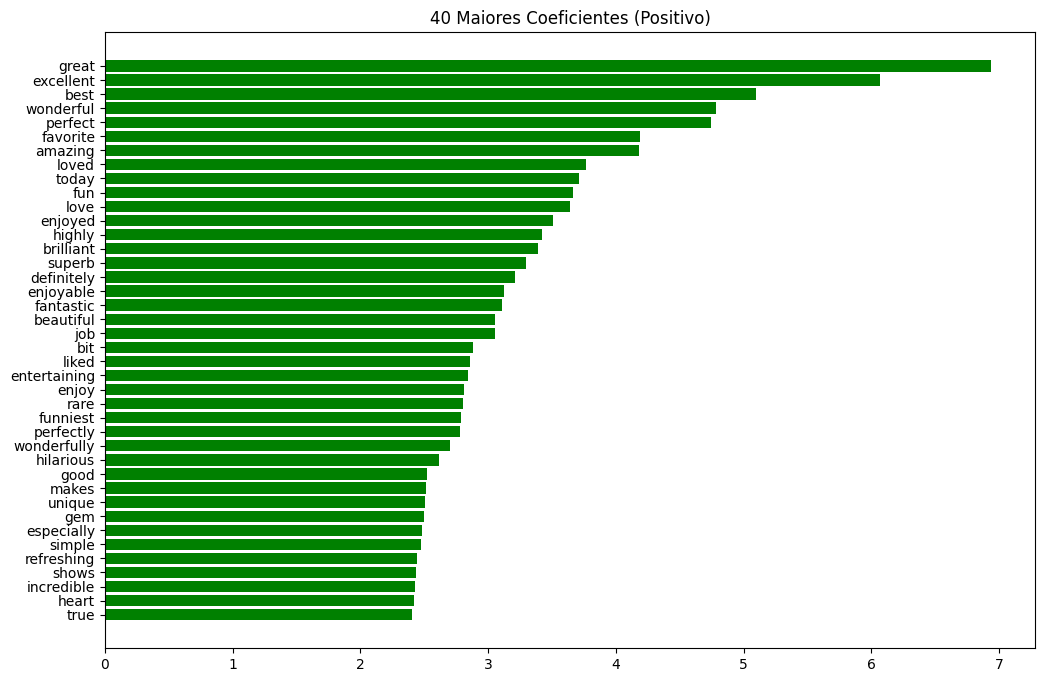

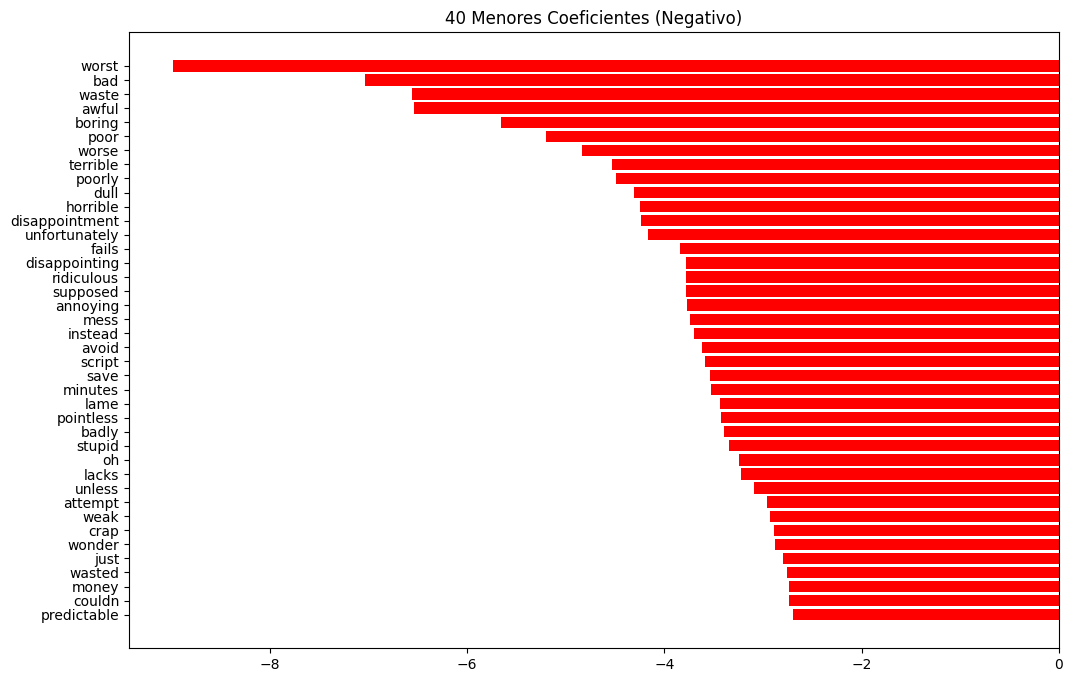

In [39]:
coeficientes = modelo.coef_.flatten()
df_coef = pd.DataFrame({'feature': features, 'coeficiente': coeficientes})

maiores_coef = df_coef.sort_values(by='coeficiente', ascending=False).head(40)
menores_coef = df_coef.sort_values(by='coeficiente').head(40)

plt.figure(figsize=(12, 8))
plt.barh(maiores_coef['feature'], maiores_coef['coeficiente'], color='green')
plt.title('40 Maiores Coeficientes (Positivo)')
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(12, 8))
plt.barh(menores_coef['feature'], menores_coef['coeficiente'], color='red')
plt.title('40 Menores Coeficientes (Negativo)')
plt.gca().invert_yaxis()
plt.show()